In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from matplotlib.colors import ListedColormap

In [2]:
df = pd.read_csv("Mall_Customers.csv")

In [3]:
df.head(8)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94


In [4]:
df.tail(8)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
192,193,Male,33,113,8
193,194,Female,38,113,91
194,195,Female,47,120,16
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


In [5]:
df.shape

(200, 5)

In [6]:
df.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [9]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [10]:
df.isnull().sum().sum()

0

In [11]:
df.duplicated()


0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [12]:
df.duplicated().sum()

0

In [13]:
df.nunique()

CustomerID                200
Gender                      2
Age                        51
Annual Income (k$)         64
Spending Score (1-100)     84
dtype: int64

In [14]:
num_cols = df.select_dtypes(include='number')

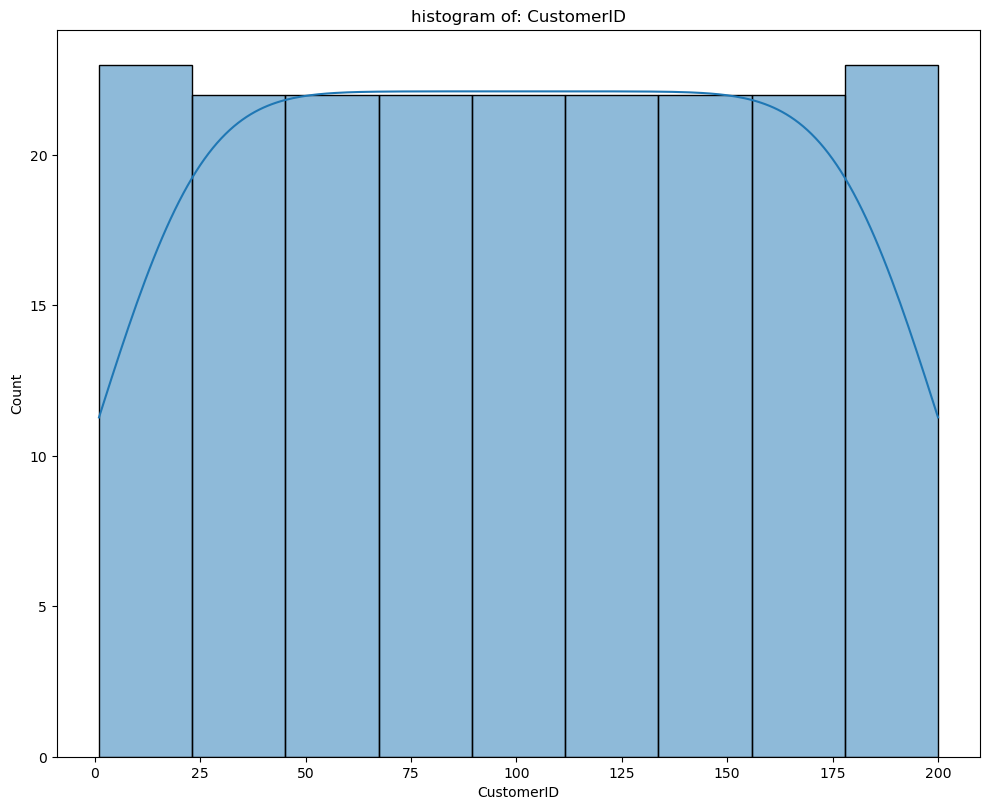

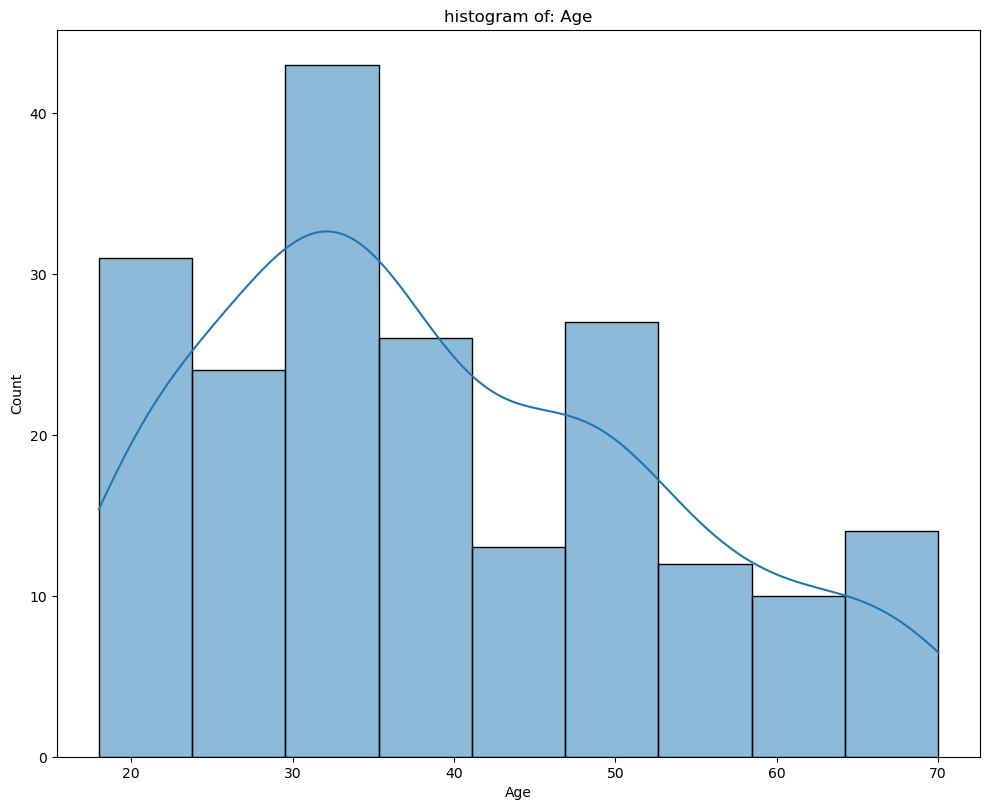

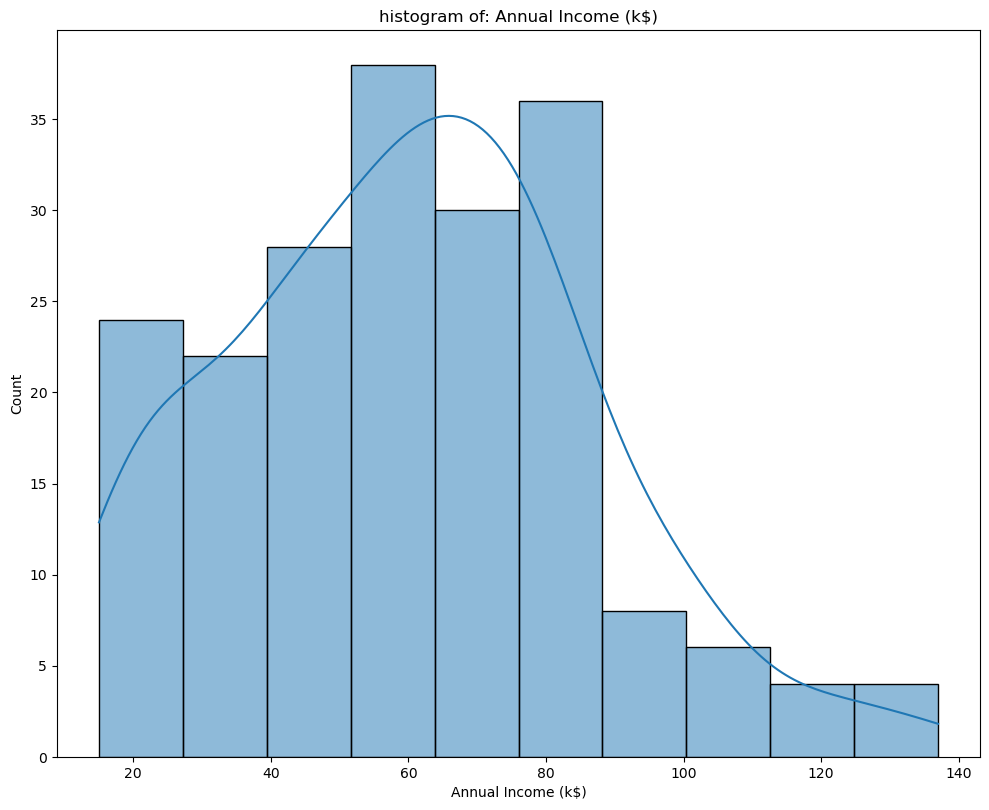

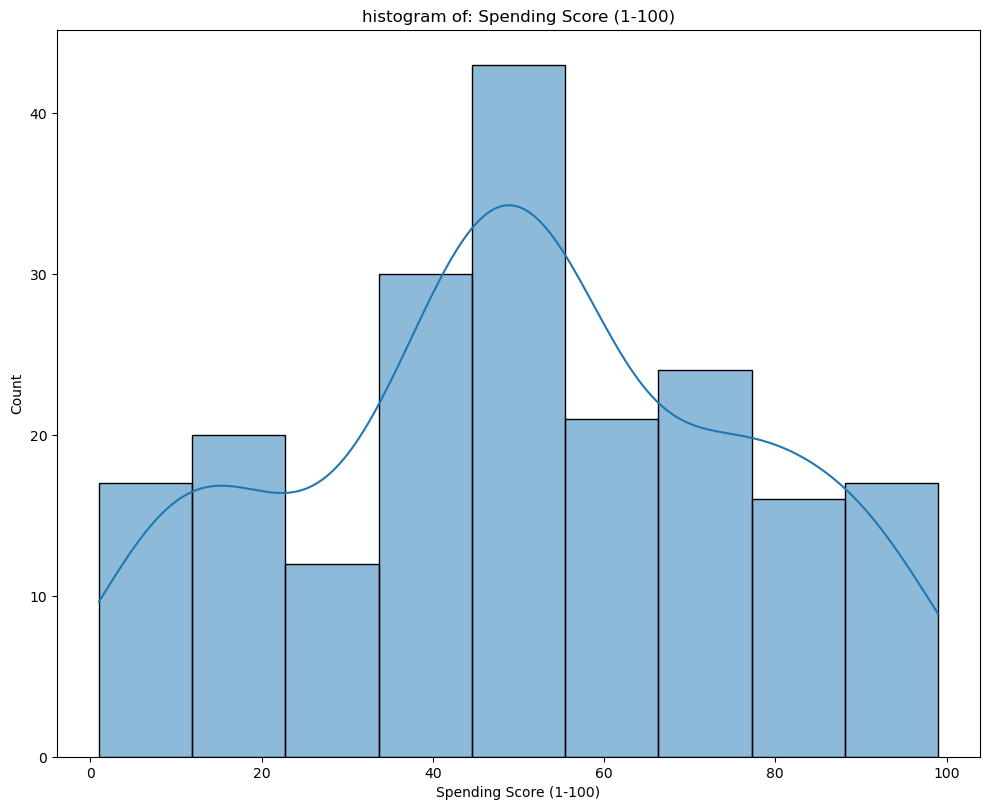

In [15]:
for i in num_cols:
    plt.figure(figsize=(10,8))
    sns.histplot(df[i],kde=True)
    plt.tight_layout()
    plt.title(f'histogram of: {i}')
    plt.show()

In [16]:
corr = df.corr(numeric_only=True)
corr

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
CustomerID,1.000000,-0.026763,0.977548,0.013835
Age,-0.026763,1.000000,-0.012398,-0.327227
Annual Income (k$),0.977548,-0.012398,1.000000,0.009903
Spending Score (1-100),0.013835,-0.327227,0.009903,1.000000


<Axes: >

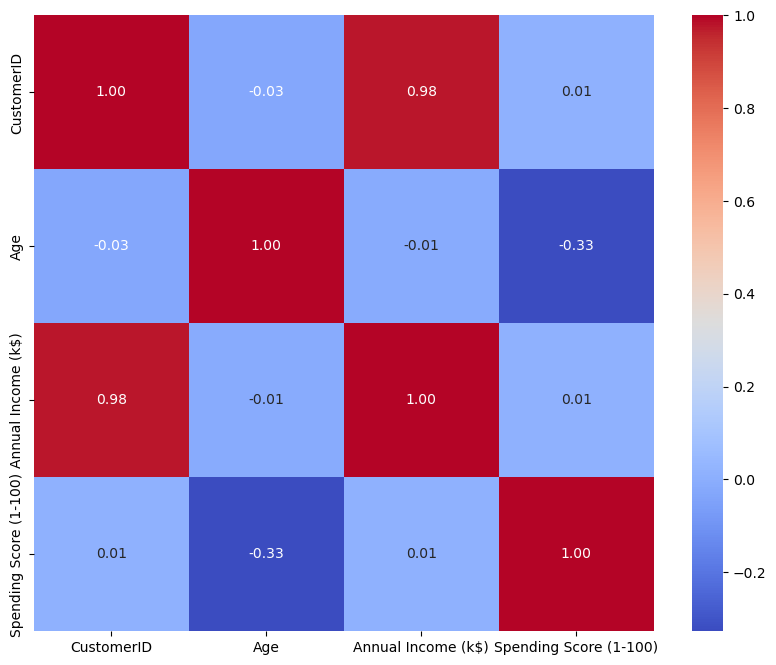

In [17]:
plt.figure(figsize=(10,8))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='coolwarm')

In [18]:
def segment(row):
    if row['Annual Income (k$)'] > 70 and row['Spending Score (1-100)'] > 60:
        return 'Premium'
    elif row['Annual Income (k$)'] > 40:
        return 'Mid-Range'
    else:
        return 'Budget'

df['Buyer_Segment'] = df.apply(segment, axis=1)

In [19]:
df['Buyer_Segment']

0         Budget
1         Budget
2         Budget
3         Budget
4         Budget
         ...    
195      Premium
196    Mid-Range
197      Premium
198    Mid-Range
199      Premium
Name: Buyer_Segment, Length: 200, dtype: object

In [20]:
df['Buyer_Segment'].value_counts()

Buyer_Segment
Mid-Range    113
Budget        50
Premium       37
Name: count, dtype: int64

In [21]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]
y = df['Buyer_Segment']

In [22]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded,
    test_size=0.2,
    random_state=42
)


In [24]:
numeric_features = X.columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features)
    ]
)


In [25]:
knn_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5, metric='euclidean'))
])


In [26]:
knn_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Annual Income (k$)',
                                                   'Spending Score '
                                                   '(1-100)'])])),
                ('classifier', KNeighborsClassifier(metric='euclidean'))])

In [27]:
y_pred = knn_pipeline.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=le.classes_))


Accuracy: 0.95
              precision    recall  f1-score   support

      Budget       1.00      0.83      0.91         6
   Mid-Range       0.97      0.97      0.97        30
     Premium       0.80      1.00      0.89         4

    accuracy                           0.95        40
   macro avg       0.92      0.93      0.92        40
weighted avg       0.96      0.95      0.95        40



In [28]:
accuracy_scores = []

for k in range(1, 21):
    knn_pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    knn_pipeline.fit(X_train, y_train)
    y_pred = knn_pipeline.predict(X_test)
    accuracy_scores.append(accuracy_score(y_test, y_pred))

print("Accuracy for different K:", accuracy_scores)


Accuracy for different K: [0.95, 0.95, 0.925, 0.95, 0.95, 0.975, 0.975, 0.95, 0.95, 0.95, 0.975, 0.975, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95, 0.95]


In [29]:
cv_scores = []

for k in range(1, 21):
    knn_pipeline = Pipeline(steps=[
        ('preprocessing', preprocessor),
        ('classifier', KNeighborsClassifier(n_neighbors=k))
    ])
    scores = cross_val_score(knn_pipeline, X, y_encoded, cv=5)
    cv_scores.append(scores.mean())

optimal_k = cv_scores.index(max(cv_scores)) + 1
print("Optimal K:", optimal_k)


Optimal K: 15


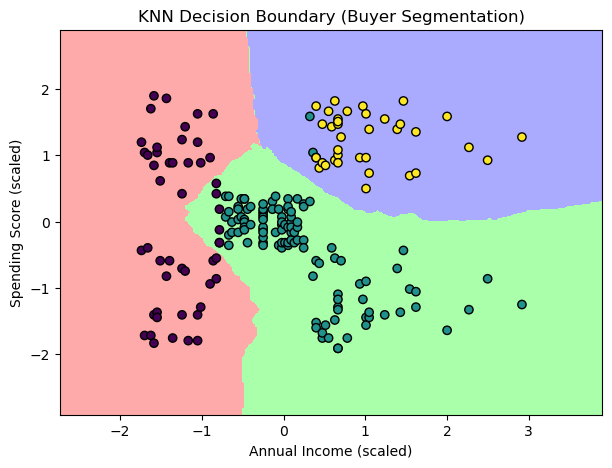

In [30]:
best_knn = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=optimal_k))
])

best_knn.fit(X, y_encoded)
#I created a mesh grid
X_scaled = best_knn.named_steps['preprocessing'].transform(X)

h = 0.02
x_min, x_max = X_scaled[:,0].min() - 1, X_scaled[:,0].max() + 1
y_min, y_max = X_scaled[:,1].min() - 1, X_scaled[:,1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

Z = best_knn.named_steps['classifier'].predict(
    np.c_[xx.ravel(), yy.ravel()]
)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, cmap=ListedColormap(['#FFAAAA','#AAFFAA','#AAAAFF']))
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=y_encoded, edgecolor='k')
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("KNN Decision Boundary (Buyer Segmentation)")
plt.show()
